# 1. Análise Exploratória dos Dados

A etapa de entendimento dos dados tem como objetivo obter uma visão aprofundada da base disponível para análise, permitindo compreender sua origem, estrutura e qualidade. Nessa fase, são examinadas as variáveis presentes no dataset, identificada a existência de valores ausentes ou inconsistências e avaliada a distribuição das classes, bem como possíveis padrões e comportamentos relevantes. Adicionalmente, são conduzidas análises descritivas e estatísticas iniciais que auxiliam na compreensão das relações entre as variáveis e no contexto geral dos dados.

Nesse contexto, foi realizada uma análise exploratória dos dados com foco na avaliação da estrutura do dataset, na distribuição das variáveis e na verificação da qualidade das informações. Foram analisadas estatísticas descritivas, investigada a presença de valores nulos e observadas possíveis relações entre variáveis relevantes para o problema de detecção de fraude. Esse entendimento inicial é fundamental para orientar as etapas subsequentes de preparação dos dados, engenharia e seleção de variáveis e modelagem, assegurando que todo o pipeline analítico seja desenvolvido sobre uma base consistente, confiável e alinhada aos objetivos do projeto.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instalação dos pacotes e importação das bibliotecas

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 71.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import mannwhitneyu

# 1.1. Visão Geral do Dataset

In [ ]:
#Leitura dos datasets principais

#Treino
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/00-Dados/train.csv')

#Teste
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/00-Dados/test.csv')

In [ ]:
train.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD
0,59383,2021-08-01 00:04:37,323,217,4.60,0
1,59384,2021-08-01 00:12:10,6,429,8.61,0
2,59385,2021-08-01 00:12:34,714,1011,64.00,0
3,59386,2021-08-01 00:15:40,266,1969,12.72,0
4,59387,2021-08-01 00:16:01,890,1482,98.88,0


In [ ]:
test.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT
0,352590,2022-01-01 00:03:14,208,640,147.24
1,352591,2022-01-01 00:26:39,851,315,13.27
2,352592,2022-01-01 00:30:30,454,27,70.52
3,352593,2022-01-01 00:31:31,677,1573,44.75
4,352594,2022-01-01 00:56:18,322,1398,37.60


In [ ]:
#Avaliar quantidade de linhas

print(f'Quantidade de linhas no dataset de treino: {train.shape[0]}')
print(f'Quantidade de linhas no dataset de teste: {test.shape[0]}')

Quantidade de linhas no dataset de treino: 291231
Quantidade de linhas no dataset de teste: 226731


In [ ]:
#Leitura dos datasets auxiliares
terminal = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/00-Dados/terminal.csv')
terminal.head()

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,9.388886,44.298820
1,1,12.204779,38.423219
2,2,16.123444,41.642938
3,3,13.341542,37.858452
4,4,11.964165,55.351051


In [ ]:
customer = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/00-Dados/customer.csv')
customer.head()

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day
0,0,10.950170,59.768684,62.262521,31.131260,2.179533
1,1,13.671851,52.775318,46.570785,23.285393,3.567092
2,2,-9.381829,38.617619,80.213879,40.106939,2.115580
3,3,-3.745116,40.551744,11.748426,5.874213,0.348517
4,4,4.312412,51.067100,78.924891,39.462446,3.480049


#1.2. Estrutura e Qualidade dos Dados

*Join entre tabelas*

Nesta etapa, foi realizada a junção (merge) das tabelas de transações de treino e teste com as tabelas auxiliares de clientes e terminais, com o objetivo de consolidar todas as informações relevantes em uma única base por transação.

Inicialmente, cada conjunto de transações é unido à tabela de clientes por meio da chave CUSTOMER_ID, incorporando informações cadastrais e comportamentais associadas a cada cliente. Em seguida, o resultado dessa junção é unido à tabela de terminais pela chave TERMINAL_ID, adicionando características relacionadas ao local onde a transação ocorreu.

Ao final do processo, obtêm-se os dataframes df_train_merged e df_test_merged, que concentram, em uma única estrutura, os dados transacionais, as informações de clientes e as características dos terminais, servindo como base para as etapas subsequentes de análise exploratória, engenharia de features e modelagem.

In [ ]:
# Treino
df_merged = pd.merge(train, customer, on='CUSTOMER_ID', how='left')
df_train_merged = pd.merge(df_merged, terminal, on='TERMINAL_ID', how='left')

# Teste
df_merged = pd.merge(test, customer, on='CUSTOMER_ID', how='left')
df_test_merged = pd.merge(df_merged, terminal, on='TERMINAL_ID', how='left')

df_train_merged.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,x_terminal_id,y_terminal_id
0,59383,2021-08-01 00:04:37,323,217,4.60,0,-0.362432,39.512573,7.353061,3.676530,3.324124,2.439994,50.324767
1,59384,2021-08-01 00:12:10,6,429,8.61,0,-0.466155,38.210214,18.618562,9.309281,3.778676,11.450431,49.902275
2,59385,2021-08-01 00:12:34,714,1011,64.00,0,-0.682848,38.095822,82.620413,41.310207,3.723765,13.616103,46.150744
3,59386,2021-08-01 00:15:40,266,1969,12.72,0,14.309093,40.607318,9.852171,4.926085,3.862067,12.286148,45.514582
4,59387,2021-08-01 00:16:01,890,1482,98.88,0,-4.209270,36.454733,83.660035,41.830018,3.128315,5.168861,51.234704


Metadados: essa função gera uma visão consolidada da qualidade e estrutura dos dados, ajudando a identificar colunas problemáticas (com muitos nulos), variáveis com alta cardinalidade ou tipos de dados incorretos, o que é fundamental para a etapa de preparação antes da modelagem.

Para cada variável do DataFrame, a função calcula:

  - nome_variavel → nome da coluna.

  - tipo → tipo de dado (int, float, object etc.).

  - qt_nulos → quantidade absoluta de valores nulos.

  - percent_nulos → percentual de valores nulos em relação ao total de linhas.

  - cardinalidade → número de valores únicos na coluna.

Depois, ela organiza as colunas em ordem decrescente de percentual de nulos e retorna uma tabela (outro DataFrame) com esse resumo.


A análise inicial dos metadados mostrou que o dataset principal está completamente preenchido, sem ocorrência de valores nulos, o que indica boa qualidade dos dados e reduz a necessidade de tratamentos adicionais nessa etapa. A base contempla informações de 998 clientes distintos, refletindo a diversidade de perfis presentes no conjunto.

Esses clientes realizaram, ao todo, 291.231 transações, um volume considerável que assegura robustez estatística para análises e modelagem. Além disso, as transações ocorreram em 1.994 terminais diferentes, evidenciando ampla cobertura geográfica e operacional da base. Esses números reforçam a representatividade do dataset e oferecem um cenário rico para a exploração de padrões de comportamento e identificação de possíveis ocorrências de fraude.

In [ ]:
# Metadados referente ao conjunto de dados
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='percent_nulos',ascending=False)
    metadata = metadata.reset_index(drop=True)

    return metadata

generate_metadata(df_train_merged)

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,TRANSACTION_ID,int64,0,0.0,291231
1,TX_DATETIME,object,0,0.0,287096
2,CUSTOMER_ID,int64,0,0.0,998
3,TERMINAL_ID,int64,0,0.0,1994
4,TX_AMOUNT,float64,0,0.0,18570
5,TX_FRAUD,int64,0,0.0,2
6,x_customer_id,float64,0,0.0,998
7,y_customer_id,float64,0,0.0,998
8,mean_amount,float64,0,0.0,998
9,std_amount,float64,0,0.0,998


Esse código enriquece a base com variáveis temporais derivadas de TX_DATETIME. Primeiro, a coluna é convertida para o formato datetime, permitindo manipulações de data e hora. Em seguida, são criadas novas variáveis: o year da transação, o PERIODO_DIA, que classifica cada registro em manhã, tarde ou noite conforme a hora, e o month_reference, que consolida ano e mês em uma única informação. Essas variáveis facilitam análises sazonais e comportamentais, além de aumentar o potencial preditivo dos modelos.

In [ ]:
# Convertendo a coluna TX_DATETIME para datetime
df_train_merged['TX_DATETIME'] = pd.to_datetime(df_train_merged['TX_DATETIME'])
df_train_merged['year'] = df_train_merged['TX_DATETIME'].dt.year

# Função para classificar o período do dia
def classify_period(hour):
    if 5 <= hour < 12:
        return 'manhã'
    elif 12 <= hour < 18:
        return 'tarde'
    else:
        return 'noite'

# Aplicar a função para criar a nova coluna 'PERIODO_DIA'
df_train_merged['PERIODO_DIA'] = df_train_merged['TX_DATETIME'].dt.hour.apply(classify_period)

# Criando a variável que indica o mês de referência
df_train_merged['month_reference'] = df_train_merged['TX_DATETIME'].dt.strftime('%Y%m')
df_train_merged

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,x_terminal_id,y_terminal_id,year,PERIODO_DIA,month_reference
0,59383,2021-08-01 00:04:37,323,217,4.60,0,-0.362432,39.512573,7.353061,3.676530,3.324124,2.439994,50.324767,2021,noite,202108
1,59384,2021-08-01 00:12:10,6,429,8.61,0,-0.466155,38.210214,18.618562,9.309281,3.778676,11.450431,49.902275,2021,noite,202108
2,59385,2021-08-01 00:12:34,714,1011,64.00,0,-0.682848,38.095822,82.620413,41.310207,3.723765,13.616103,46.150744,2021,noite,202108
3,59386,2021-08-01 00:15:40,266,1969,12.72,0,14.309093,40.607318,9.852171,4.926085,3.862067,12.286148,45.514582,2021,noite,202108
4,59387,2021-08-01 00:16:01,890,1482,98.88,0,-4.209270,36.454733,83.660035,41.830018,3.128315,5.168861,51.234704,2021,noite,202108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291226,350609,2021-12-30 23:33:02,221,41,61.26,0,16.458186,48.474966,78.232912,39.116456,2.943576,0.726690,51.074300,2021,noite,202112
291227,350610,2021-12-30 23:46:15,101,761,58.80,0,-4.763890,37.754536,36.036584,18.018292,0.930977,10.757077,47.182099,2021,noite,202112
291228,350611,2021-12-30 23:54:38,7,1991,15.08,0,14.722394,49.992092,30.132783,15.066392,3.096935,11.532585,60.306354,2021,noite,202112
291229,350612,2021-12-30 23:56:36,161,1166,54.24,0,-3.076024,43.274381,70.068772,35.034386,2.627048,-2.184463,42.013333,2021,noite,202112




Os testes de sanidade têm como objetivo validar se os dados estão consistentes e se os números básicos fazem sentido antes de avançar para análises mais complexas ou modelagem. Eles funcionam como uma espécie de "checagem de saúde" do dataset.

Entre os principais pontos avaliados estão:

- Taxa de fraude na base: proporção de transações fraudulentas em relação ao total, útil para entender o nível de desbalanceamento da variável alvo.

- Taxa de fraude por mês de referência: permite verificar se existem variações sazonais relevantes na ocorrência de fraudes.

- Taxa de fraude por terminal: identifica terminais mais suscetíveis a fraudes, possibilitando análises de risco.

- Volume de transações por mês e por terminal: avalia se a distribuição do volume é uniforme ou concentrada em determinados períodos ou locais.

- Volume de clientes envolvidos em fraudes ao longo do tempo: mostra a evolução da quantidade de clientes impactados.

- Volume de dinheiro nas transações fraudulentas: indica o impacto financeiro, tanto no total quanto por período de referência.

- Volume de transações e valores por período do dia: ajuda a identificar janelas de tempo mais críticas para ocorrência de fraudes.

## 1.3. Análise das Transações

In [ ]:
# Estatística descritiva
df_train_merged.describe()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,x_terminal_id,y_terminal_id,year
count,291231.000000,291231,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.000000,291231.0
mean,204998.000000,2021-10-16 02:06:44.044813056,496.256202,993.718526,53.182274,0.022601,6.369599,46.715810,51.710394,25.855197,2.650934,6.929841,46.906274,2021.0
min,59383.000000,2021-08-01 00:04:37,0.000000,0.000000,0.000000,0.000000,-15.722968,36.442978,5.063101,2.531550,0.018782,-16.913020,34.480700,2021.0
25%,132190.500000,2021-09-08 05:17:43.500000,249.000000,496.000000,21.130000,0.000000,-0.691936,40.348956,28.606102,14.303051,1.956902,0.274440,40.835133,2021.0
50%,204998.000000,2021-10-16 05:55:26,498.000000,1000.000000,44.770000,0.000000,8.429219,48.108743,51.641807,25.820903,2.836935,8.534868,47.972450,2021.0
75%,277805.500000,2021-11-23 06:15:18.500000,741.000000,1483.000000,76.850000,0.000000,12.479186,51.567670,75.288972,37.644486,3.438147,12.748856,51.636076,2021.0
max,350613.000000,2021-12-30 23:58:21,999.000000,1999.000000,291.150000,1.000000,25.192465,60.406826,99.981815,49.990907,3.999725,26.843163,64.060717,2021.0
std,84071.292461,NaN,285.274966,575.267551,39.573329,0.148627,8.551536,6.486223,27.475610,13.737805,0.961907,8.708658,6.408352,0.0


O conjunto de dados apresenta um total de 291.231 transações registradas, das quais 2,26% foram classificadas como fraudulentas

## Volume de transações e taxa de fraude por mês de referência

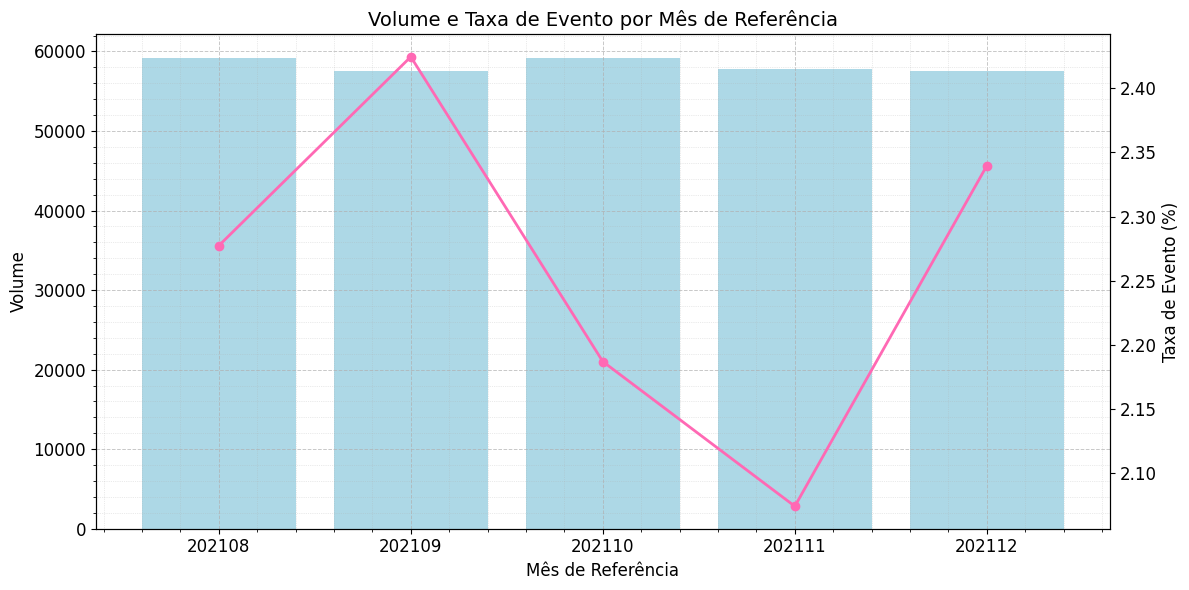

In [ ]:
# Preparando os DataFrames
df_ref_vol = df_train_merged.groupby('month_reference')['TRANSACTION_ID'].count().reset_index().rename(columns={'TRANSACTION_ID': 'Volume'})
df_ref_fraud = df_train_merged.groupby('month_reference')['TX_FRAUD'].mean().reset_index()
df_plot = pd.merge(df_ref_fraud, df_ref_vol, how='inner', on='month_reference')

# Gráfico com barras para o volume e linha para a taxa de evento por month_reference
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotando o gráfico de barras para o volume
color_bar = 'lightblue'
ax1.bar(df_plot['month_reference'], df_plot['Volume'], color=color_bar, label='Volume')
ax1.set_xlabel('Mês de Referência', fontsize=12, color='black')
ax1.set_ylabel('Volume', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# Configurando eixos menores para melhorar a visualização do grid
ax1.minorticks_on()

# Plotando o gráfico de linha para a taxa de fraude
color_line = 'hotpink'
ax2 = ax1.twinx()  # Cria um segundo eixo y
ax2.plot(df_plot['month_reference'], df_plot['TX_FRAUD'] * 100, marker='o', linestyle='-', color=color_line, linewidth=2, markersize=6, label='Taxa de Evento (%)')
ax2.set_ylabel('Taxa de Evento (%)', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

# Ajustando a fonte e cor dos labels dos eixos
for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontsize(12)
    label.set_color('black')

plt.title('Volume e Taxa de Evento por Mês de Referência', fontsize=14, color='black')
fig.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.show()

In [ ]:
df_plot

,month_reference,TX_FRAUD,Volume
0,202108,0.022773,59193
1,202109,0.024244,57582
2,202110,0.021871,59166
3,202111,0.020744,57800
4,202112,0.023395,57490


A análise temporal mostra que a taxa de fraude variou entre 2,42% e 2,07%, com o valor mais alto registrado em setembro de 2021 e o mais baixo em novembro de 2021. Apesar dessas oscilações, o volume total de transações manteve-se estável ao longo dos meses, indicando que as variações observadas estão mais relacionadas à ocorrência de fraudes do que a mudanças significativas no número de operações realizadas.

## Volume de transações e taxa de fraude por terminal

### Ordenando por terminais com maior taxa de fraude

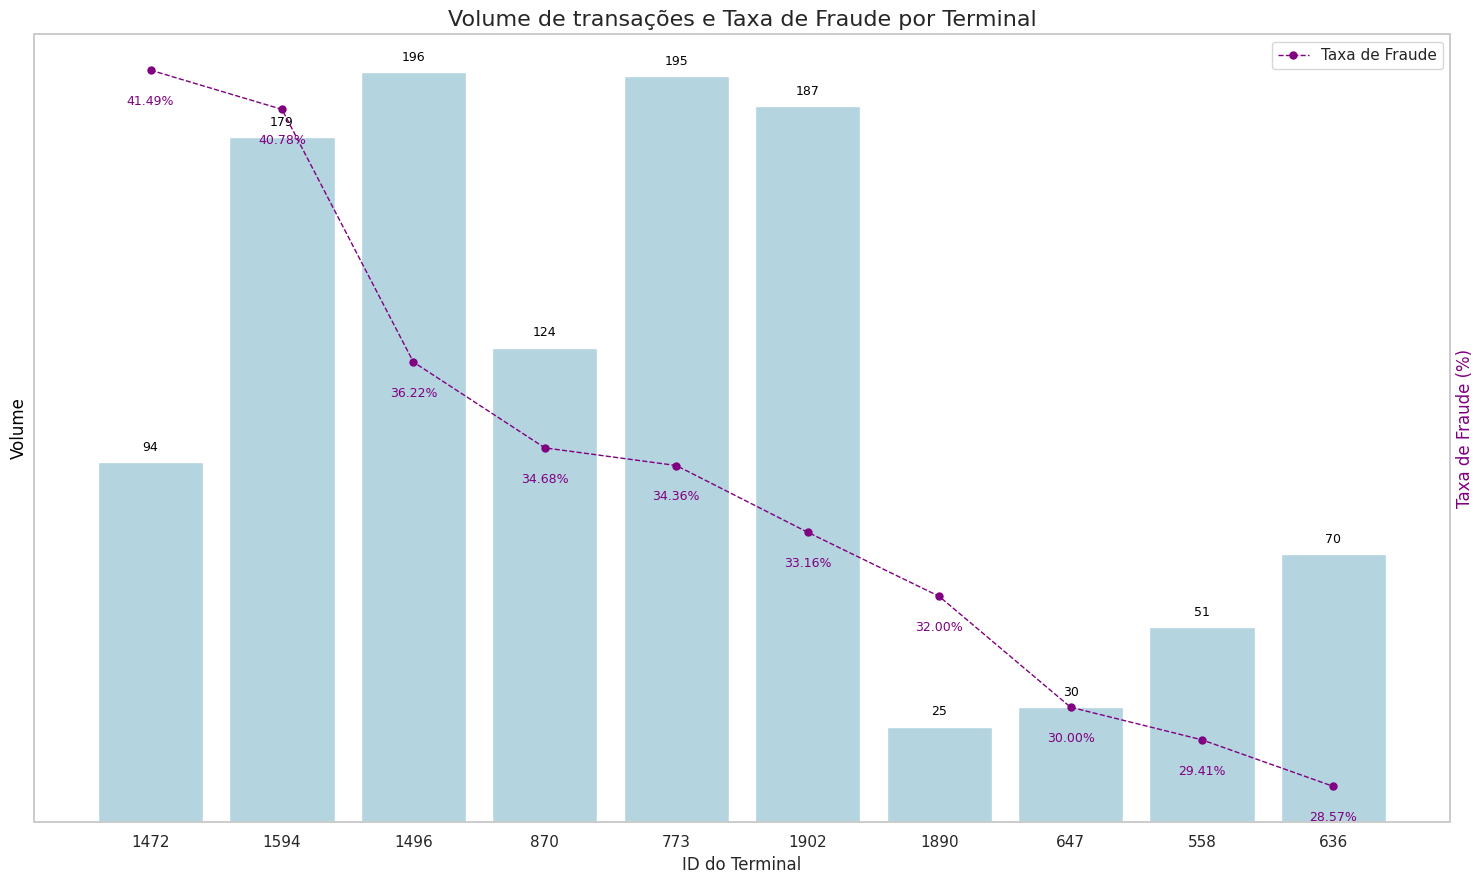

In [ ]:
df_ref_vol = df_train_merged.groupby('TERMINAL_ID')['TRANSACTION_ID'].count().reset_index().rename(columns={'TRANSACTION_ID': 'VOLUME'})
df_ref_fraud = df_train_merged.groupby('TERMINAL_ID')['TX_FRAUD'].mean().reset_index()
df_plot = pd.merge(df_ref_fraud, df_ref_vol, how='inner', on='TERMINAL_ID')
df_plot = df_plot.sort_values(by=['TX_FRAUD','VOLUME'],ascending=False)[:10].copy()

# Definindo o estilo do seaborn
sns.set(style="whitegrid")

# Criando a figura e o eixo
fig, ax1 = plt.subplots(figsize=(15, 9))

# Plotando o gráfico de barras
barplot = sns.barplot(x=df_plot['TERMINAL_ID'].astype(str),
                      y=df_plot['VOLUME'],
                      color='lightblue',
                      ax=ax1)

# Criando o segundo eixo y para a linha de TX_FRAUD
ax2 = ax1.twinx()
lineplot = ax2.plot(df_plot['TERMINAL_ID'].astype(str),
                     df_plot['TX_FRAUD'],
                     color='purple',
                     marker='o',
                     linestyle='--',
                     linewidth=1,
                     markersize=5,
                     label='Taxa de Fraude')

# Ajustando os rótulos e título
ax1.set_xlabel('ID do Terminal', fontsize=12)
ax1.set_ylabel('Volume', fontsize=12, color='black')
ax2.set_ylabel('Taxa de Fraude (%)', fontsize=12, color='purple')
plt.title('Volume de transações e Taxa de Fraude por Terminal', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='purple')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Removendo todas as linhas de grade
ax1.grid(False)
ax2.grid(False)

# Removendo números dos eixos verticais
ax1.set_yticks([])
ax2.set_yticks([])

# Adicionando rótulos nas barras
for i in range(len(df_plot)):
    total_value = df_plot['VOLUME'].iloc[i]
    ax1.annotate(f'{total_value}',
                 (df_plot['TERMINAL_ID'].astype(str).iloc[i], df_plot['VOLUME'].iloc[i]),
                 textcoords="offset points", xytext=(0,8), ha='center', fontsize=9, color='black')

# Adicionando rótulos na curva
for i in range(len(df_plot)):
    fraud_rate = df_plot['TX_FRAUD'].iloc[i]
    ax2.annotate(f'{100*fraud_rate:.2f}%',
                 (df_plot['TERMINAL_ID'].astype(str).iloc[i], df_plot['TX_FRAUD'].iloc[i]),
                 textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9, color='purple')

# Adicionando a legenda para a linha de TX_FRAUD
ax2.legend(['Taxa de Fraude'], loc='upper right')

# Ajustando o layout para melhor visualização
plt.tight_layout()

# Exibindo o gráfico
plt.show()

### Ordenando por terminais com maior volume de transações

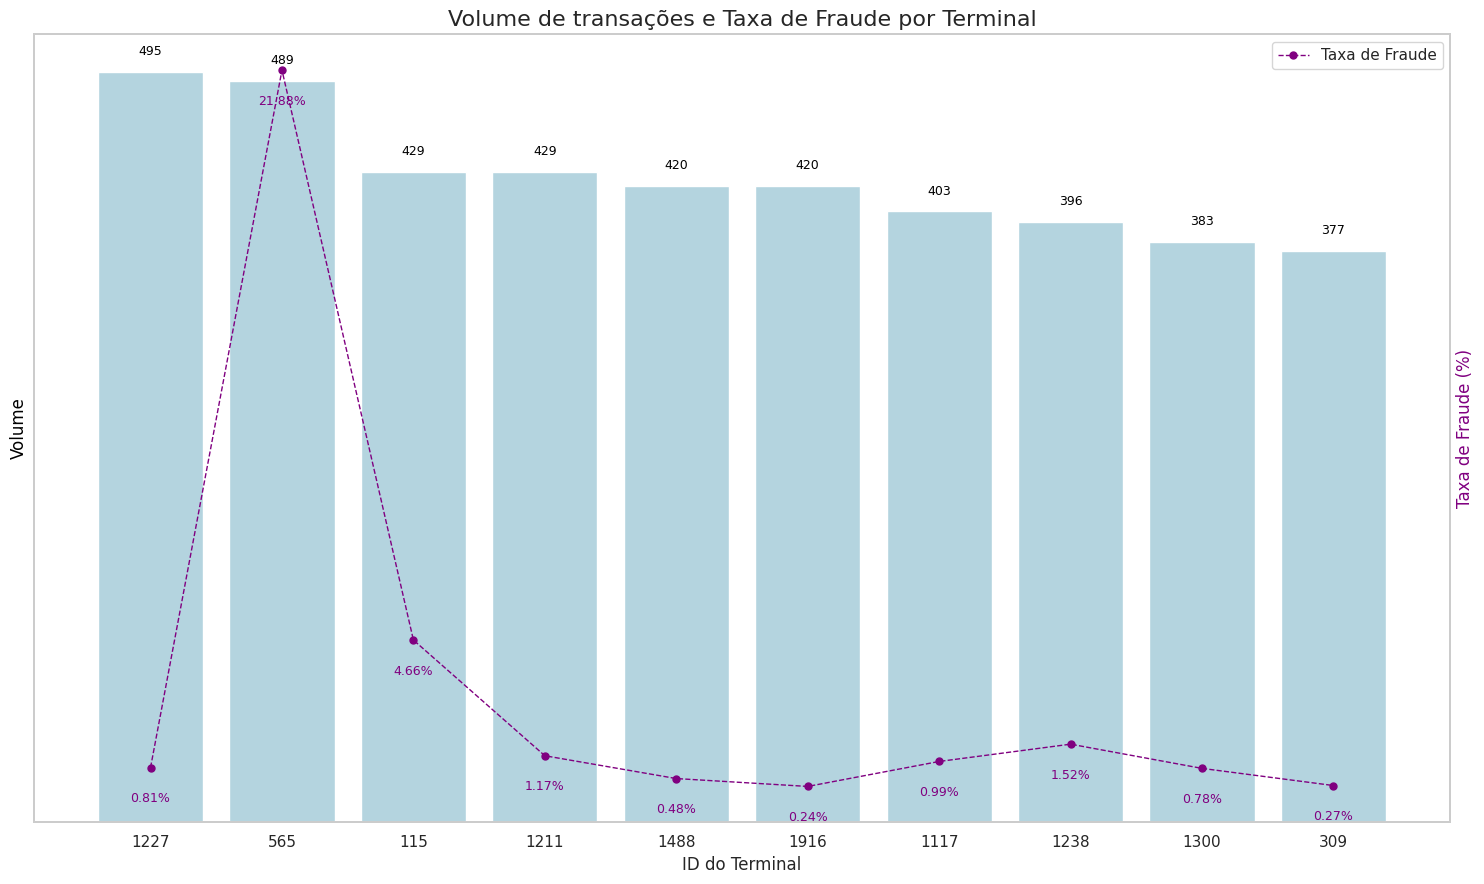

In [ ]:
df_ref_vol = df_train_merged.groupby('TERMINAL_ID')['TRANSACTION_ID'].count().reset_index().rename(columns={'TRANSACTION_ID': 'VOLUME'})
df_ref_fraud = df_train_merged.groupby('TERMINAL_ID')['TX_FRAUD'].mean().reset_index()
df_plot = pd.merge(df_ref_fraud, df_ref_vol, how='inner', on='TERMINAL_ID')
df_plot = df_plot.sort_values(by=['VOLUME','TX_FRAUD'],ascending=False)[:10].copy()

# Definindo o estilo do seaborn
sns.set(style="whitegrid")

# Criando a figura e o eixo
fig, ax1 = plt.subplots(figsize=(15, 9))

# Plotando o gráfico de barras
barplot = sns.barplot(x=df_plot['TERMINAL_ID'].astype(str),
                      y=df_plot['VOLUME'],
                      color='lightblue',
                      ax=ax1)

# Criando o segundo eixo y para a linha de TX_FRAUD
ax2 = ax1.twinx()
lineplot = ax2.plot(df_plot['TERMINAL_ID'].astype(str),
                     df_plot['TX_FRAUD'],
                     color='purple',
                     marker='o',
                     linestyle='--',
                     linewidth=1,
                     markersize=5,
                     label='Taxa de Fraude')

# Ajustando os rótulos e título
ax1.set_xlabel('ID do Terminal', fontsize=12)
ax1.set_ylabel('Volume', fontsize=12, color='black')
ax2.set_ylabel('Taxa de Fraude (%)', fontsize=12, color='purple')
plt.title('Volume de transações e Taxa de Fraude por Terminal', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='purple')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Removendo todas as linhas de grade
ax1.grid(False)
ax2.grid(False)

# Removendo números dos eixos verticais
ax1.set_yticks([])
ax2.set_yticks([])

# Adicionando rótulos nas barras
for i in range(len(df_plot)):
    total_value = df_plot['VOLUME'].iloc[i]
    ax1.annotate(f'{total_value}',
                 (df_plot['TERMINAL_ID'].astype(str).iloc[i], df_plot['VOLUME'].iloc[i]),
                 textcoords="offset points", xytext=(0,12), ha='center', fontsize=9, color='black')

# Adicionando rótulos na curva
for i in range(len(df_plot)):
    fraud_rate = df_plot['TX_FRAUD'].iloc[i]
    ax2.annotate(f'{100*fraud_rate:.2f}%',
                 (df_plot['TERMINAL_ID'].astype(str).iloc[i], df_plot['TX_FRAUD'].iloc[i]),
                 textcoords="offset points", xytext=(0,-25), ha='center', fontsize=9, color='purple')

# Adicionando a legenda para a linha de TX_FRAUD
ax2.legend(['Taxa de Fraude'], loc='upper right')

# Ajustando o layout para melhor visualização
plt.tight_layout()

# Exibindo o gráfico
plt.show()

O terminal 565 se destaca por concentrar o segundo maior volume de transações (489) e, ao mesmo tempo, apresentar uma taxa de fraude extremamente elevada, aproximadamente 9,68 vezes superior à taxa média da base. Esse comportamento indica um ponto crítico de risco, sugerindo que esse terminal pode estar diretamente associado a práticas fraudulentas recorrentes e merece atenção especial em análises de segurança e estratégias de monitoramento.

In [ ]:
# Razão entre a taxa de fraude no terminal 565 e a taxa média
df_plot.iloc[1].TX_FRAUD/df_train_merged.TX_FRAUD.mean()

np.float64(9.681767340935401)

## Volume de clientes que estiveram envolvidos em alguma transação fraudulenta e por mês de referência

In [ ]:
# Calculando a quantidade de clientes envolvidos em transações fraudulentas
qtd_clientes_fraud = df_train_merged[df_train_merged.TX_FRAUD == 1].CUSTOMER_ID.nunique()

# Total de clientes
total_clientes = df_train_merged.CUSTOMER_ID.nunique()

# Calculando a representação percentual
percentual_fraud = 100 * qtd_clientes_fraud / total_clientes

print(f'Quantidade de clientes envolvidos em alguma transação fraudulenta no período: {qtd_clientes_fraud}\nTotal de clientes: {total_clientes}\nRepresentação percentual {percentual_fraud:.2f}%')

Quantidade de clientes envolvidos em alguma transação fraudulenta no período: 750
Total de clientes: 998
Representação percentual 75.15%


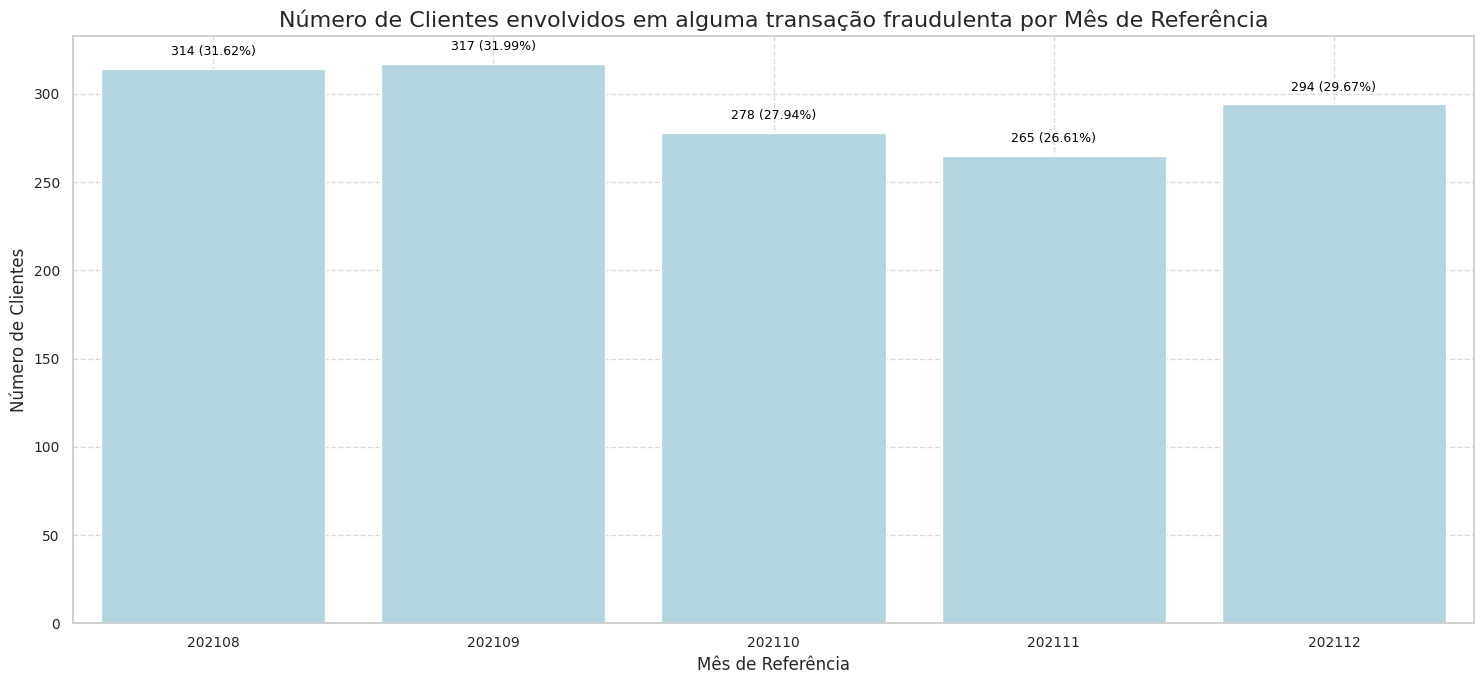

In [ ]:
df_total_customers = df_train_merged.groupby('month_reference')['CUSTOMER_ID'].nunique().reset_index()
df_total_customers = df_total_customers.rename(columns={'CUSTOMER_ID': 'Total_Customers'})

df_fraud_customers = df_train_merged[df_train_merged.TX_FRAUD == 1].groupby('month_reference')['CUSTOMER_ID'].nunique().reset_index()
df_fraud_customers = df_fraud_customers.rename(columns={'CUSTOMER_ID': 'Fraud_Customers'})

# Mesclando os DataFrames para ter total e fraudulento juntos
df_comparison = pd.merge(df_total_customers, df_fraud_customers, on='month_reference', how='inner')
df_comparison['Percent_Fraud'] = (df_comparison['Fraud_Customers'] / df_comparison['Total_Customers']) * 100

# Definindo o estilo do seaborn
sns.set(style="whitegrid")

# Plotando o gráfico de barras
plt.figure(figsize=(15, 7))
barplot = sns.barplot(x=df_comparison['month_reference'].astype(str),
                      y=df_comparison['Fraud_Customers'],
                      color='lightblue')

# Ajustando os rótulos e título
plt.xlabel('Mês de Referência', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.title('Número de Clientes envolvidos em alguma transação fraudulenta por Mês de Referência', fontsize=16)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Adicionando anotações para número de clientes e percentual
for i in range(len(df_comparison)):
    num_clients = df_comparison['Fraud_Customers'].iloc[i]
    percent_fraud = df_comparison['Percent_Fraud'].iloc[i]
    plt.annotate(f'{num_clients} ({percent_fraud:.2f}%)',
                 (df_comparison['month_reference'].astype(str).iloc[i], df_comparison['Fraud_Customers'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='black')

plt.show()

Em setembro de 2021, um total de 317 clientes esteve envolvido em transações fraudulentas, o que corresponde a 31,99% dos clientes ativos no período. Já em novembro de 2021, esse número caiu para 265 clientes, representando 26,61% do total. Essa redução indica uma diminuição na proporção de clientes impactados por fraudes, embora o volume ainda seja significativo e mereça acompanhamento contínuo.

## Volume de dinheiro nas transações fraudulentas no período e por mês de referência

Valor total envolvido em transações fraudulentas no período: 376210.13


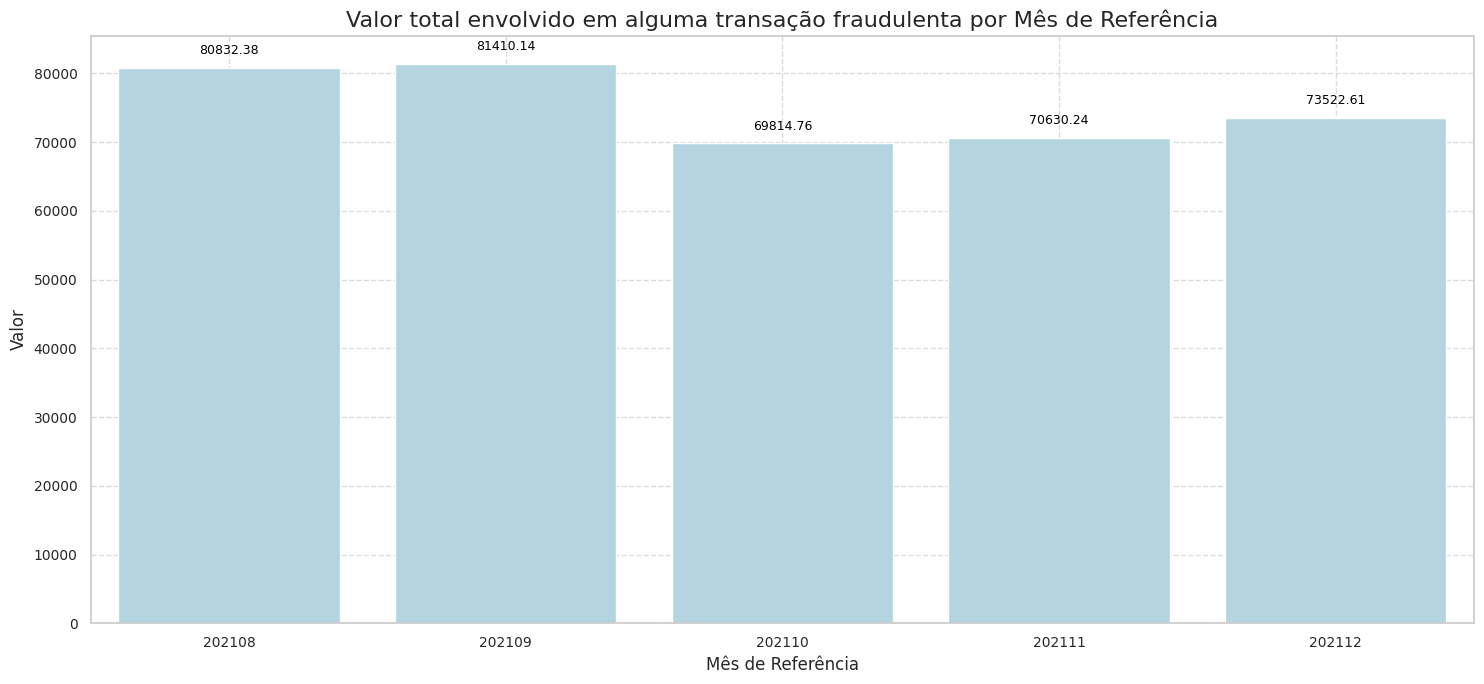

In [ ]:
df_amount = df_train_merged[df_train_merged.TX_FRAUD == 1].groupby('month_reference')['TX_AMOUNT'].sum().reset_index()

valor_total = df_amount.TX_AMOUNT.sum()

# Definindo o estilo do seaborn
sns.set(style="whitegrid")

# Plotando o gráfico de barras
plt.figure(figsize=(15, 7))
barplot = sns.barplot(x=df_amount['month_reference'].astype(str),
                      y=df_amount['TX_AMOUNT'],
                      color='lightblue')

# Ajustando os rótulos e título
plt.xlabel('Mês de Referência', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.title('Valor total envolvido em alguma transação fraudulenta por Mês de Referência', fontsize=16)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Adicionando anotações para número de clientes e percentual
for i in range(len(df_amount)):
    total_value_month_ref = df_amount['TX_AMOUNT'].iloc[i]
    plt.annotate(f'{total_value_month_ref}',
                 (df_amount['month_reference'].astype(str).iloc[i], df_amount['TX_AMOUNT'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='black')

print(f'Valor total envolvido em transações fraudulentas no período: {valor_total}')

plt.show()

O mês de setembro de 2021 destaca-se como o mais crítico, concentrando o maior valor total associado a transações fraudulentas, enquanto outubro apresenta uma redução significativa, seguida por uma recuperação gradual nos meses subsequentes.

## Distribuição de valor de transação por grupo (Fraude / Não Fraude)

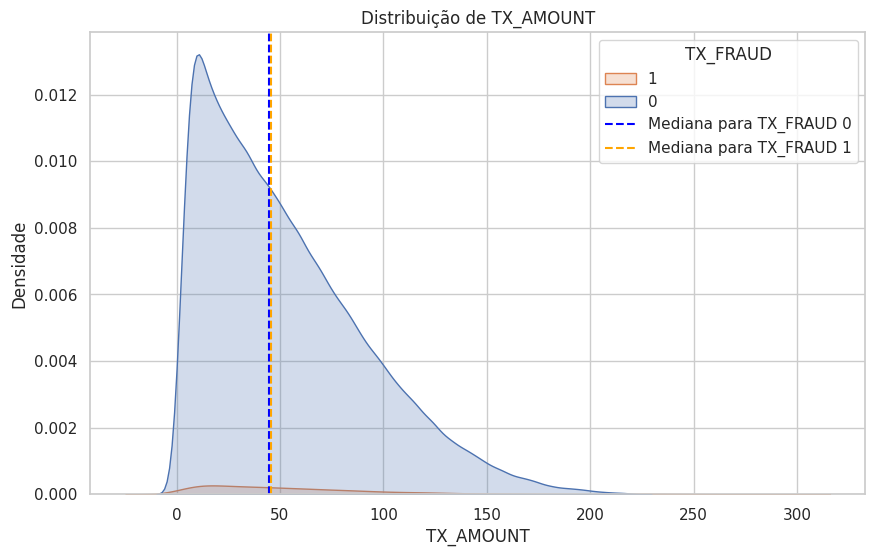

In [ ]:
var = 'TX_AMOUNT'

# Calcular as medianas para cada grupo
medianas = df_train_merged.groupby('TX_FRAUD')[var].median()

colors = ['blue','orange']
i = 0

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train_merged, x=var, hue='TX_FRAUD', fill=True, warn_singular=False)

# Adicionar linhas verticais representando as medianas
for target, mediana in medianas.items():
    plt.axvline(x=mediana, linestyle='--', color=colors[i], label=f'Mediana para TX_FRAUD {target}')
    i += 1

plt.title(f'Distribuição de {var}')
plt.ylabel('Densidade')
plt.xlabel(f'{var}')
plt.legend(title='TX_FRAUD', loc='upper right', labels=['1', '0', 'Mediana para TX_FRAUD 0', 'Mediana para TX_FRAUD 1'])
plt.show()

O gráfico apresenta a distribuição do valor das transações (TX_AMOUNT) para operações legítimas e fraudulentas. Observa-se que a variável possui uma distribuição assimétrica à direita, com predominância de transações de baixo valor e uma cauda longa associada a valores mais elevados, característica comum em dados financeiros.

Nota-se que as transações fraudulentas apresentam valores, em média, superiores aos das transações legítimas, conforme evidenciado pelo deslocamento da distribuição e pela mediana mais elevada no grupo fraudulento. Esse resultado sugere que fraudes tendem a envolver montantes maiores, aumentando o impacto financeiro mesmo com menor frequência de ocorrência.

Entretanto, verifica-se uma significativa sobreposição entre as distribuições, indicando que o valor da transação, isoladamente, não é suficiente para distinguir fraudes de operações legítimas. Assim, TX_AMOUNT deve ser utilizado em conjunto com outras variáveis contextuais e temporais para uma detecção de fraude mais eficaz.

### Teste de Mann-Whitney U (Não paramétrico)

In [ ]:
# Definindo os dois grupos
amostra1 = df_train_merged[train.TX_FRAUD == 0]['TX_AMOUNT']
amostra2 = df_train_merged[train.TX_FRAUD == 1]['TX_AMOUNT']

In [ ]:
# Realizando o teste de Mann-Whitney U
stat, p_value = mannwhitneyu(amostra1, amostra2, alternative='less')

print(f'Estatística U: {stat}')
print(f'Valor p: {p_value}')

if p_value < 0.05:
    print("Rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa entre os grupos.")
else:
    print("Não rejeitamos a hipótese nula. Não podemos afirmar que há diferença estatisticamente significativa entre os grupos.")

Estatística U: 918469532.5
Valor p: 0.0033098149945866543
Rejeitamos a hipótese nula. Há uma diferença estatisticamente significativa entre os grupos.


Para checar se há diferença estatisticamente significativa entre os valores das transações legítimas e fraudulentas, foi aplicado o teste não paramétrico de Mann–Whitney U, adequado para distribuições assimétricas e sem suposição de normalidade.

Os resultados obtidos (U = 918.469.532,5; valor-p = 0,0033) indicam a rejeição da hipótese nula ao nível de significância de 5%, evidenciando que os valores das transações fraudulentas diferem estatisticamente dos valores das transações legítimas. Esse resultado confirma que a variável TX_AMOUNT possui relevância estatística para a distinção entre os dois grupos, reforçando sua importância como feature no contexto da detecção de fraude, embora deva ser utilizada em conjunto com outras variáveis para uma classificação mais robusta.

# 2.5. Análise Tempora e Contextual

## Volume de transações, dinheiro por período do dia

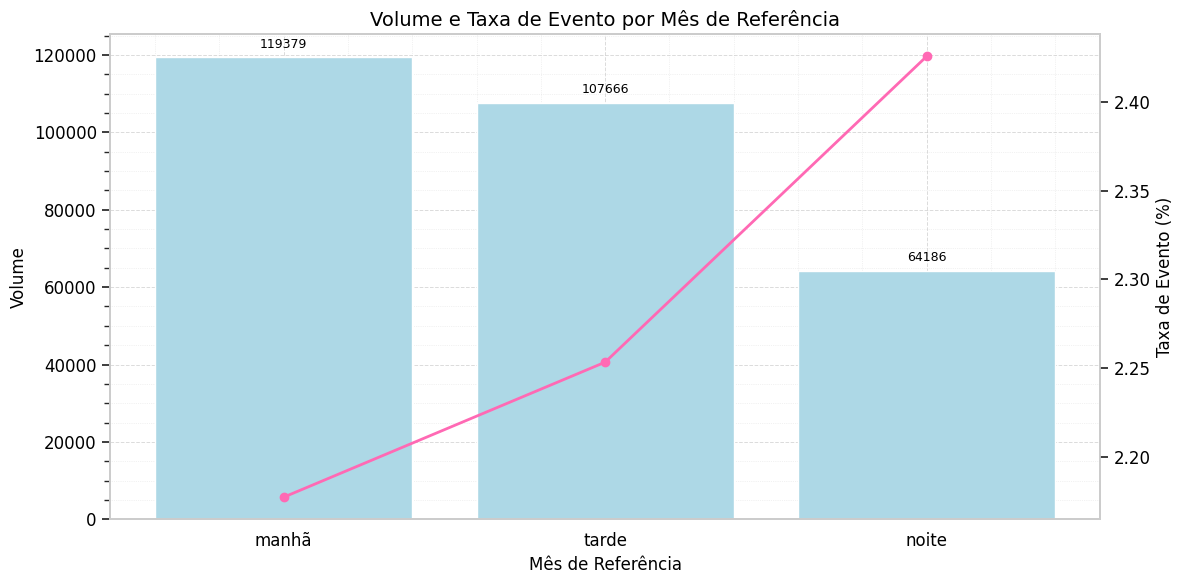

In [ ]:
# Preparando os DataFrames
df_ref_vol = df_train_merged.groupby('PERIODO_DIA')['TRANSACTION_ID'].count().reset_index().rename(columns={'TRANSACTION_ID': 'Volume'})
df_ref_fraud = df_train_merged.groupby('PERIODO_DIA')['TX_FRAUD'].mean().reset_index()
df_plot = pd.merge(df_ref_fraud, df_ref_vol, how='inner', on='PERIODO_DIA')

# Definir uma ordem personalizada para a coluna 'PERIODO_DIA'
ordem_periodos = ['manhã', 'tarde', 'noite']
df_plot['PERIODO_DIA'] = pd.Categorical(df_plot['PERIODO_DIA'], categories=ordem_periodos, ordered=True)

# Ordenar o DataFrame pela coluna 'PERIODO_DIA'
df_plot = df_plot.sort_values(by='PERIODO_DIA')

# Gráfico com barras para o volume e linha para a taxa de evento por PERIODO_DIA
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotando o gráfico de barras para o volume
color_bar = 'lightblue'
ax1.bar(df_plot['PERIODO_DIA'], df_plot['Volume'], color=color_bar, label='Volume')
ax1.set_xlabel('Mês de Referência', fontsize=12, color='black')
ax1.set_ylabel('Volume', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# Configurando eixos menores para melhorar a visualização do grid
ax1.minorticks_on()

# Plotando o gráfico de linha para a taxa de fraude
color_line = 'hotpink'
ax2 = ax1.twinx()  # Cria um segundo eixo y
ax2.plot(df_plot['PERIODO_DIA'], df_plot['TX_FRAUD'] * 100, marker='o', linestyle='-', color=color_line, linewidth=2, markersize=6, label='Taxa de Evento (%)')
ax2.set_ylabel('Taxa de Evento (%)', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

# Ajustando a fonte e cor dos labels dos eixos
for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontsize(12)
    label.set_color('black')

# Adicionando rótulos nas barras
for i in range(len(df_plot)):
    total_value = df_plot['Volume'].iloc[i]
    ax1.annotate(f'{total_value}',
                 (df_plot['PERIODO_DIA'].astype(str).iloc[i], df_plot['Volume'].iloc[i]),
                 textcoords="offset points", xytext=(0,7), ha='center', fontsize=9, color='black')

plt.title('Volume e Taxa de Evento por Mês de Referência', fontsize=14, color='black')
fig.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.show()

A análise por período do dia revela que o maior volume de transações ocorre pela manhã e à tarde, refletindo os horários de maior movimentação dos clientes. No entanto, a taxa de fraude é mais elevada durante a noite, indicando que esse período concentra maior risco e pode demandar estratégias específicas de monitoramento e prevenção.

In [ ]:
df_plot

,PERIODO_DIA,TX_FRAUD,Volume
0,manhã,0.021771,119379
2,tarde,0.022533,107666
1,noite,0.024258,64186


### Distribuição de valor de transação para os grupos (TX_FRAUD = 0 / TX_FRAUD = 1) por período do dia

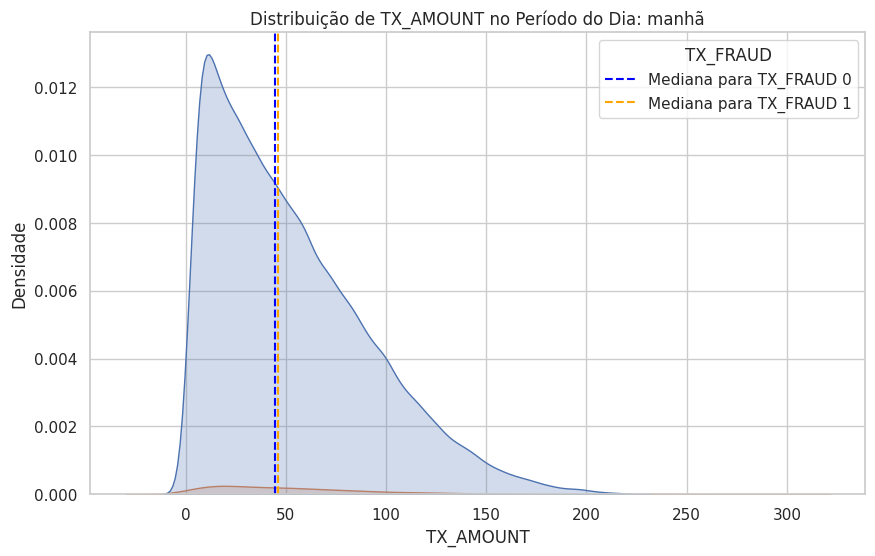

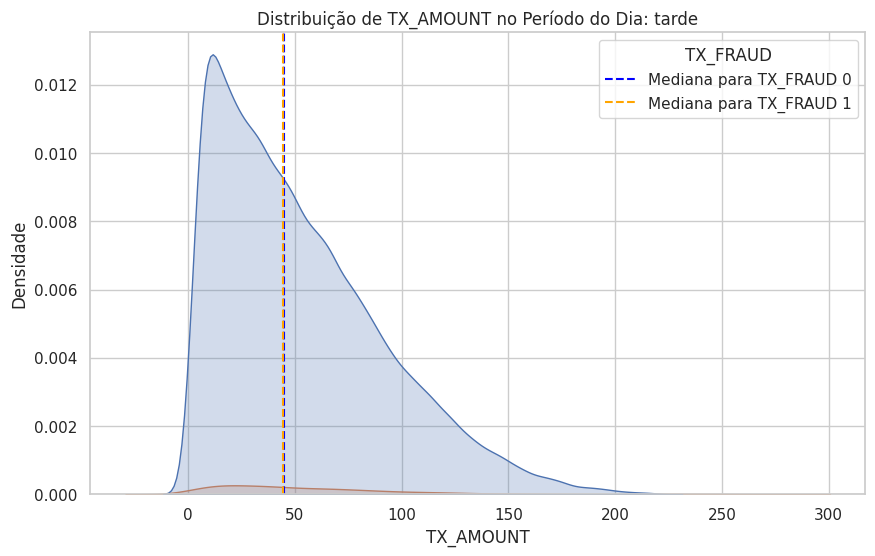

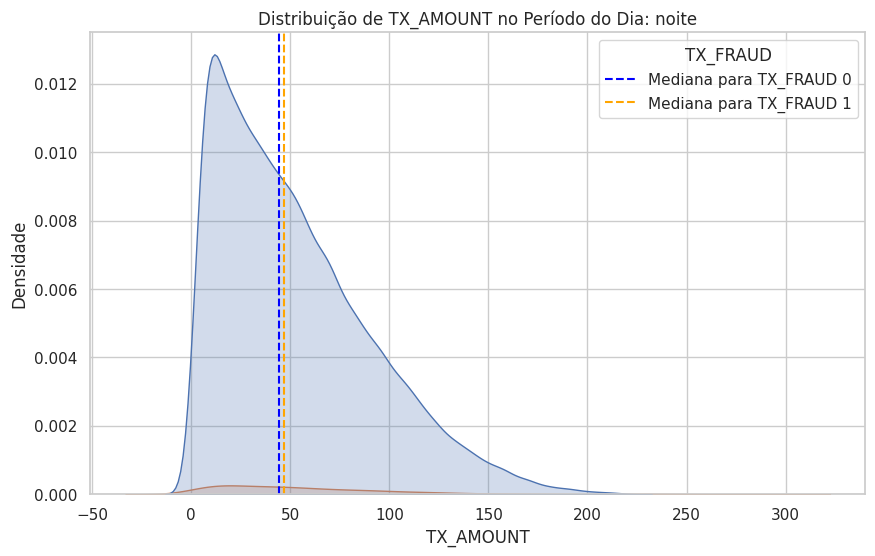

In [ ]:
# Definir cores
colors = ['blue', 'orange']

# Iterar sobre cada período do dia e plotar o gráfico correspondente
for periodo in ordem_periodos:
    plt.figure(figsize=(10, 6))

    # Filtrar os dados para o período atual
    subset = df_train_merged[df_train_merged['PERIODO_DIA'] == periodo]

    # Calcular as medianas para cada grupo
    medianas = subset.groupby('TX_FRAUD')['TX_AMOUNT'].median()

    # Plotar a densidade
    sns.kdeplot(data=subset, x='TX_AMOUNT', hue='TX_FRAUD', fill=True, warn_singular=False)

    # Adicionar linhas verticais representando as medianas
    for i, (target, mediana) in enumerate(medianas.items()):
        plt.axvline(x=mediana, linestyle='--', color=colors[i], label=f'Mediana para TX_FRAUD {target}')

    plt.title(f'Distribuição de TX_AMOUNT no Período do Dia: {periodo}')
    plt.ylabel('Densidade')
    plt.xlabel('TX_AMOUNT')
    plt.legend(title='TX_FRAUD', loc='upper right')
    plt.show()

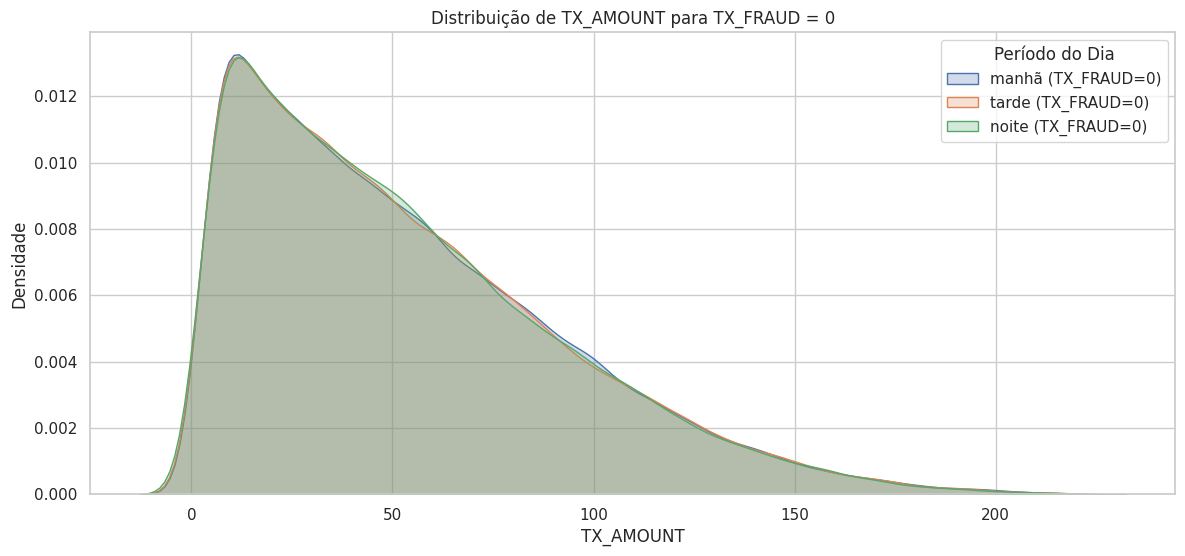

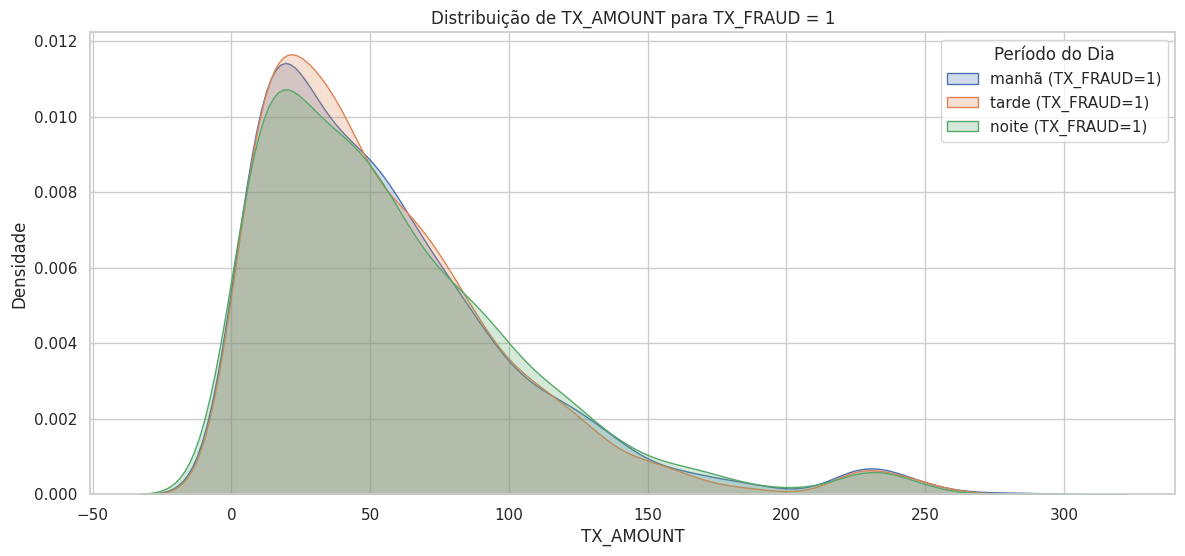

In [ ]:
# Plot para TX_FRAUD = 0
plt.figure(figsize=(14, 6))
for periodo in ordem_periodos:
    subset = df_train_merged[(df_train_merged['PERIODO_DIA'] == periodo) & (df_train_merged['TX_FRAUD'] == 0)]
    sns.kdeplot(data=subset, x='TX_AMOUNT', fill=True, label=f'{periodo} (TX_FRAUD=0)', warn_singular=False)

plt.title('Distribuição de TX_AMOUNT para TX_FRAUD = 0')
plt.ylabel('Densidade')
plt.xlabel('TX_AMOUNT')
plt.legend(title='Período do Dia')
plt.show()

# Plot para TX_FRAUD = 1
plt.figure(figsize=(14, 6))
for periodo in ordem_periodos:
    subset = df_train_merged[(df_train_merged['PERIODO_DIA'] == periodo) & (df_train_merged['TX_FRAUD'] == 1)]
    sns.kdeplot(data=subset, x='TX_AMOUNT', fill=True, label=f'{periodo} (TX_FRAUD=1)', warn_singular=False)

plt.title('Distribuição de TX_AMOUNT para TX_FRAUD = 1')
plt.ylabel('Densidade')
plt.xlabel('TX_AMOUNT')
plt.legend(title='Período do Dia')
plt.show()

O gráfico apresenta a distribuição do valor das transações fraudulentas (TX_AMOUNT), segmentadas por período do dia (manhã, tarde e noite). Observa-se que, independentemente do período, as distribuições apresentam formato semelhante, caracterizado por assimetria à direita e predominância de transações de menor valor, com ocorrência menos frequente de valores elevados.

Verifica-se uma forte sobreposição entre as curvas correspondentes aos diferentes períodos, indicando que o valor das transações fraudulentas não varia significativamente ao longo do dia. Embora pequenas diferenças possam ser observadas, como uma leve maior dispersão de valores elevados no período noturno, tais variações são sutis e não permitem uma distinção clara entre os grupos quando considerada apenas essa variável.

Esses resultados sugerem que o período do dia, isoladamente, possui baixo poder discriminativo sobre o valor das fraudes, mas pode contribuir como variável complementar quando combinada com outras informações contextuais, como características do terminal, do cliente ou do histórico temporal das transações.

## Visualização gráfica dos terminais

### Localizações dos clientes

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


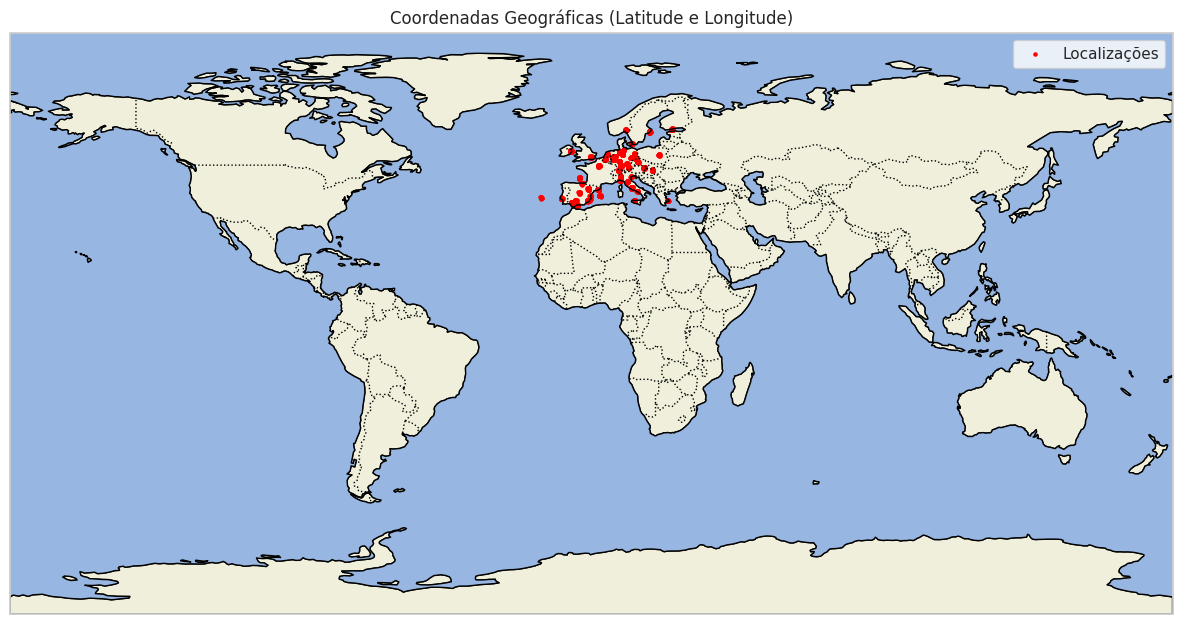

In [ ]:
# Criando o plot com Cartopy
plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())  # Define a projeção para o gráfico
ax.set_extent([-180, 180, -90, 90])  # Define os limites do gráfico (global)

# Adiciona características ao mapa como costas, estados e países
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)

# Plotando as coordenadas no mapa
plt.scatter(customer['x_customer_id'], customer['y_customer_id'],
            color='red', marker='o', s=5, transform=ccrs.PlateCarree(),
            label='Localizações')

plt.title('Coordenadas Geográficas (Latitude e Longitude)')
plt.legend()
plt.show()

### Localizações dos terminais

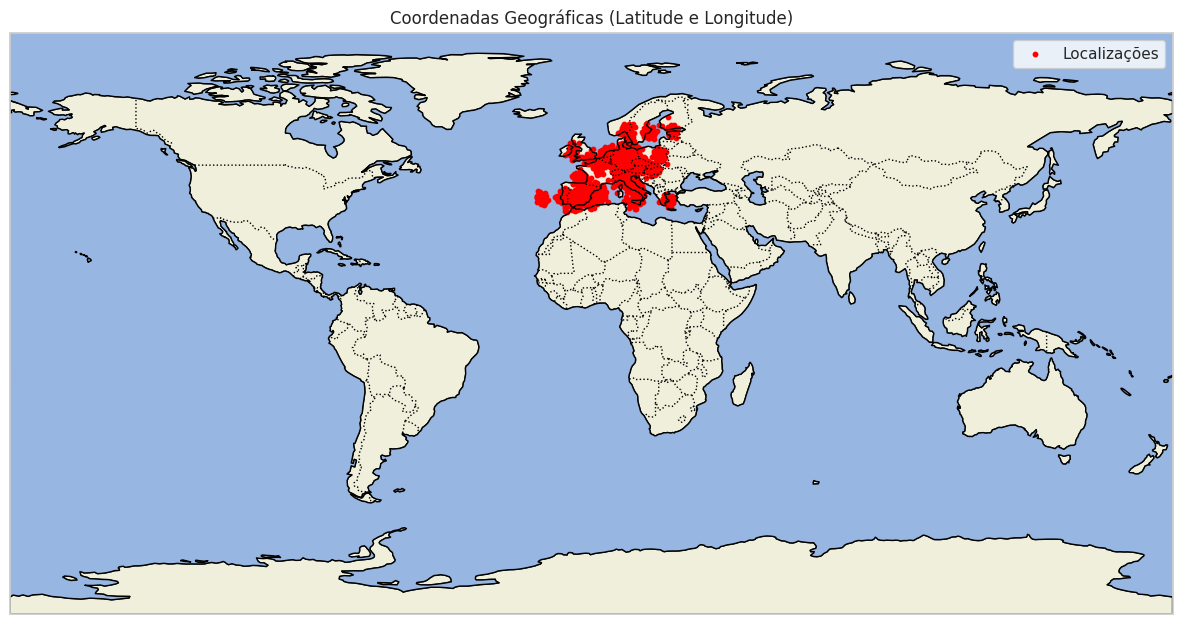

In [ ]:
# Criando o plot com Cartopy
plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())  # Define a projeção para o gráfico
ax.set_extent([-180, 180, -90, 90])  # Define os limites do gráfico (global)

# Adiciona características ao mapa como costas, estados e países
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)

# Plotando as coordenadas no mapa
plt.scatter(terminal['x_terminal_id'], terminal['y_terminal_id'],
            color='red', marker='o', s=10, transform=ccrs.PlateCarree(),
            label='Localizações')

plt.title('Coordenadas Geográficas (Latitude e Longitude)')
plt.legend()
plt.show()